# Readmission-DL — End-to-End Pipeline

This notebook trains a model to predict 30-day readmission and saves artifacts for inference.

In [55]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.model_selection import StratifiedKFold


## Preprocessing

In [57]:
def fit_preprocessor(df):
    df = df.copy()

    df['admission_date'] = pd.to_datetime(df['admission_date'], errors='coerce')
    df['admission_month'] = df['admission_date'].dt.month
    df['admission_month'] = df['admission_month'].fillna(df['admission_month'].median())

    df['glucose_missing'] = df['glucose_level_mgdl'].isnull().astype(int)
    glucose_median = df['glucose_level_mgdl'].median()
    df['glucose_level_mgdl'] = df['glucose_level_mgdl'].fillna(glucose_median)
    df['length_of_stay_days'] = np.log1p(df['length_of_stay_days'])
    df = df.fillna(0)

    df['age'] = df['age'].replace(999, np.nan)
    df['age'] = df['age'].fillna(df['age'].median())
    df = df.drop(columns=['patient_id', 'admission_date'])

    y = df['readmitted_30d']
    X = df.drop(columns=['readmitted_30d'])

    X = pd.get_dummies(X)
    columns = X.columns

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, y.values, scaler, columns, glucose_median


In [58]:
def transform(df, scaler, columns, glucose_median):
    df = df.copy()

    df['admission_date'] = pd.to_datetime(df['admission_date'], errors='coerce')
    df['admission_month'] = df['admission_date'].dt.month
    df['admission_month'] = df['admission_month'].fillna(df['admission_month'].median())

    df['glucose_missing'] = df['glucose_level_mgdl'].isnull().astype(int)
    df['glucose_level_mgdl'] = df['glucose_level_mgdl'].fillna(glucose_median)

    df.loc[df['blood_pressure_systolic'] < 50, 'blood_pressure_systolic'] = np.nan
    df['blood_pressure_systolic'] = df['blood_pressure_systolic'].fillna(
        df['blood_pressure_systolic'].median()
    )
    patient_ids = df['patient_id']
    df['high_comorbidity'] = (df['charlson_comorbidity_index'] >= 4).astype(int)

    df['length_of_stay_days'] = np.log1p(df['length_of_stay_days'])
    df['prior_admissions_1yr'] = np.log1p(df['prior_admissions_1yr'])
    df['n_medications_discharge'] = np.log1p(df['n_medications_discharge'])
    df = df.fillna(0)

    df = df.drop(columns=['patient_id', 'admission_date'])

    X = pd.get_dummies(df)
    X = X.reindex(columns=columns, fill_value=0)

    return scaler.transform(X), patient_ids

## Create `predict.py` script

In [68]:
%%writefile /content/predict.py
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import pickle
import argparse

# Define the MLP class (must be identical to the one used for training)
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),  # First hidden layer with 128 units
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.4),
            nn.Linear(128, 64),   # Second hidden layer with 64 units
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            nn.Linear(64, 32),    # Third hidden layer with 32 units
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.1),
            nn.Linear(32, 1)      # Output layer
        )

    def forward(self, x):
        return self.net(x)

# Define the transform function (must be identical to the one used for training)
def transform(df, scaler, columns, glucose_median):
    df = df.copy()

    df['admission_date'] = pd.to_datetime(df['admission_date'], errors='coerce')
    df['admission_month'] = df['admission_date'].dt.month
    df['admission_month'] = df['admission_month'].fillna(df['admission_month'].median())

    df['glucose_missing'] = df['glucose_level_mgdl'].isnull().astype(int)
    df['glucose_level_mgdl'] = df['glucose_level_mgdl'].fillna(glucose_median)

    df.loc[df['blood_pressure_systolic'] < 50, 'blood_pressure_systolic'] = np.nan
    df['blood_pressure_systolic'] = df['blood_pressure_systolic'].fillna(
        df['blood_pressure_systolic'].median()
    )
    patient_ids = df['patient_id'] # Keep patient_ids for output
    df['high_comorbidity'] = (df['charlson_comorbidity_index'] >= 4).astype(int)

    df['length_of_stay_days'] = np.log1p(df['length_of_stay_days'])
    df['prior_admissions_1yr'] = np.log1p(df['prior_admissions_1yr'])
    df['n_medications_discharge'] = np.log1p(df['n_medications_discharge'])
    df = df.fillna(0)

    df = df.drop(columns=['patient_id', 'admission_date']) # Drop columns not used in model

    X = pd.get_dummies(df)
    X = X.reindex(columns=columns, fill_value=0)

    return scaler.transform(X), patient_ids

def main():
    parser = argparse.ArgumentParser(description='Run inference for 30-day readmission prediction.')
    parser.add_argument('--input', type=str, required=True, help='Path to the input CSV file for prediction.')
    parser.add_argument('--output', type=str, default='predictions.csv', help='Path to save the predictions CSV file.')
    args = parser.parse_args()

    # Define the artifact path (adjust if your artifacts are elsewhere)
    artifact_path = '/content/drive/MyDrive/readmission-dl/data/'

    print(f"Loading input data from: {args.input}")
    input_df = pd.read_csv(args.input)

    print("Loading preprocessing and model artifacts...")
    with open(artifact_path + 'scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)
    with open(artifact_path + 'columns.pkl', 'rb') as f:
        columns = pickle.load(f)
    with open(artifact_path + 'glucose_median.pkl', 'rb') as f:
        glucose_median = pickle.load(f)
    with open(artifact_path + 'model_paths_for_ensemble.pkl', 'rb') as f:
        model_paths_for_ensemble = pickle.load(f)
    with open(artifact_path + 'calibrator.pkl', 'rb') as f:
        calibrator = pickle.load(f)
    with open(artifact_path + 'threshold.pkl', 'rb') as f:
        best_t = pickle.load(f)

    print("Preprocessing input data...")
    X_transformed, patient_ids = transform(input_df, scaler, columns, glucose_median)
    X_tensor = torch.tensor(X_transformed, dtype=torch.float32)

    print("Performing ensembled predictions...")
    all_fold_predictions = []
    for model_path in model_paths_for_ensemble:
        # Determine input_dim from the columns used in preprocessing
        input_dim = len(columns)
        model = MLP(input_dim)
        model.load_state_dict(torch.load(model_path))
        model.eval()

        with torch.no_grad():
            probs = torch.sigmoid(model(X_tensor)).numpy().flatten()
            all_fold_predictions.append(probs)

    ensembled_probs = np.mean(all_fold_predictions, axis=0)

    print("Applying Platt scaling and decision threshold...")
    calibrated_probs = calibrator.predict_proba(ensembled_probs.reshape(-1,1))[:,1]
    predictions = (calibrated_probs > best_t).astype(int)

    output_df = pd.DataFrame({
        'patient_id': patient_ids,
        'readmitted_30d_prediction': predictions,
        'readmitted_30d_probability': calibrated_probs
    })

    output_df.to_csv(args.output, index=False)
    print(f"Predictions saved to: {args.output}")

if __name__ == '__main__':
    main()

Writing /content/predict.py


The `predict.py` script has been written to `/content/predict.py`.

To run this script from the terminal, you can use the following command:

```bash
python /content/predict.py --input /path/to/your/test_data.csv --output /path/to/save/predictions.csv
```

For example, if your test data is at `/content/drive/MyDrive/readmission-dl/data/test.csv`, and you want to save predictions in the same directory, you would run:

```bash
python /content/predict.py --input /content/drive/MyDrive/readmission-dl/data/test.csv --output /content/drive/MyDrive/readmission-dl/data/predictions.csv
```

Make sure the input CSV file (`test.csv` in the example) exists at the specified path.

# Load the logged losses
with open('/content/drive/MyDrive/readmission-dl/data/train_losses_per_fold.pkl','rb') as f:
    all_train_losses_per_fold = pickle.load(f)
with open('/content/drive/MyDrive/readmission-dl/data/val_losses_per_fold.pkl','rb') as f:
    all_val_losses_per_fold = pickle.load(f)

# Convert to numpy arrays for easier averaging
train_losses_np = np.array(all_train_losses_per_fold)
val_losses_np = np.array(all_val_losses_per_fold)

# Calculate the average loss across folds for each epoch
avg_train_losses = np.mean(train_losses_np, axis=0)
avg_val_losses = np.mean(val_losses_np, axis=0)

# Plotting the average loss curves
plt.figure(figsize=(10, 6))
plt.plot(avg_train_losses, label='Average Training Loss')
plt.plot(avg_val_losses, label='Average Validation Loss')
plt.title('Average Training and Validation Loss Over Epochs (Across Folds)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Model

In [59]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),  # First hidden layer with 128 units
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.4),
            nn.Linear(128, 64),   # Second hidden layer with 64 units
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            nn.Linear(64, 32),    # Third hidden layer with 32 units
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.1),
            nn.Linear(32, 1)      # Output layer
        )

    def forward(self, x):
        return self.net(x)

## Training

In [60]:
train_df = pd.read_csv('/content/drive/MyDrive/readmission-dl/data/train.csv')

X, y, scaler, columns, glucose_median = fit_preprocessor(train_df)

# Split into a training set for K-fold and a final test set for threshold tuning
# This ensures the final threshold tuning is done on unseen data after model training
X_kfold, X_final_test, y_kfold, y_final_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_fold_aucs = []
# List to store the paths of the best model for each fold
# We will use these to ensemble predictions later
model_paths_for_ensemble = []

# New: Lists to store losses for plotting
all_train_losses_per_fold = []
all_val_losses_per_fold = []

for fold, (train_index, val_index) in enumerate(skf.split(X_kfold, y_kfold)):
    print(f"\n--- Fold {fold+1} ---")

    X_train_fold, X_val_fold = X_kfold[train_index], X_kfold[val_index]
    y_train_fold, y_val_fold = y_kfold[train_index], y_kfold[val_index]

    X_train_fold = torch.tensor(X_train_fold, dtype=torch.float32)
    X_val_fold = torch.tensor(X_val_fold, dtype=torch.float32)
    y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32).view(-1,1)
    y_val_fold = torch.tensor(y_val_fold, dtype=torch.float32).view(-1,1)

    # Calculate pos_weight for the current fold's training data
    pos_weight = (len(y_train_fold) - y_train_fold.sum()) / y_train_fold.sum()
    pos_weight = torch.tensor([pos_weight.item()])

    # Initialize a new model, criterion, and optimizer for each fold
    model = MLP(X_train_fold.shape[1])
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-4
    )
    # Add learning rate scheduler
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    fold_best_auc = 0
    fold_best_model_state = None

    # New: Lists to store losses for current fold
    current_fold_train_losses = []
    current_fold_val_losses = []

    for epoch in range(30):
        model.train()
        logits = model(X_train_fold)
        loss = criterion(logits, y_train_fold)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step() # Step the scheduler after optimizer update

        current_fold_train_losses.append(loss.item()) # Store training loss

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_fold)
            val_loss = criterion(val_logits, y_val_fold).item() # Calculate validation loss
            probs = torch.sigmoid(val_logits).numpy().flatten()
            auc = roc_auc_score(y_val_fold, probs)

        current_fold_val_losses.append(val_loss) # Store validation loss

        # print(f"  Epoch {epoch} | Loss {loss.item():.4f} | AUC {auc:.4f}") # Uncomment to see epoch-level details

        if auc > fold_best_auc:
            fold_best_auc = auc
            fold_best_model_state = model.state_dict() # Store the best model state for this fold

    all_fold_aucs.append(fold_best_auc)
    print(f"Fold {fold+1} Best Validation AUC: {fold_best_auc:.4f}")

    # Save the best model from this fold
    fold_model_path = f'/content/drive/MyDrive/readmission-dl/data/model_fold_{fold+1}.pt'
    torch.save(fold_best_model_state, fold_model_path)
    model_paths_for_ensemble.append(fold_model_path)
    print(f"Best model for Fold {fold+1} saved to {fold_model_path}")

    # New: Store current fold's losses
    all_train_losses_per_fold.append(current_fold_train_losses)
    all_val_losses_per_fold.append(current_fold_val_losses)

print(f"\nAverage AUC across all folds: {np.mean(all_fold_aucs):.4f}")
print(f"Standard deviation of AUCs: {np.std(all_fold_aucs):.4f}")

# Save X_final_test and y_final_test for later use in threshold tuning and ensembling
with open('/content/drive/MyDrive/readmission-dl/data/X_final_test.pkl','wb') as f:
    pickle.dump(X_final_test, f)
with open('/content/drive/MyDrive/readmission-dl/data/y_final_test.pkl','wb') as f:
    pickle.dump(y_final_test, f)
print("Final test sets (X_final_test.pkl, y_final_test.pkl) saved for threshold tuning.")

# Save the list of model paths for ensembling
with open('/content/drive/MyDrive/readmission-dl/data/model_paths_for_ensemble.pkl', 'wb') as f:
    pickle.dump(model_paths_for_ensemble, f)
print("List of best model paths for ensembling saved to /content/drive/MyDrive/readmission-dl/data/model_paths_for_ensemble.pkl")

# New: Save the logged losses for plotting
with open('/content/drive/MyDrive/readmission-dl/data/train_losses_per_fold.pkl','wb') as f:
    pickle.dump(all_train_losses_per_fold, f)
with open('/content/drive/MyDrive/readmission-dl/data/val_losses_per_fold.pkl','wb') as f:
    pickle.dump(all_val_losses_per_fold, f)
print("Training and Validation losses per fold saved.")


--- Fold 1 ---
Fold 1 Best Validation AUC: 0.9230
Best model for Fold 1 saved to /content/drive/MyDrive/readmission-dl/data/model_fold_1.pt

--- Fold 2 ---
Fold 2 Best Validation AUC: 0.9288
Best model for Fold 2 saved to /content/drive/MyDrive/readmission-dl/data/model_fold_2.pt

--- Fold 3 ---
Fold 3 Best Validation AUC: 0.9092
Best model for Fold 3 saved to /content/drive/MyDrive/readmission-dl/data/model_fold_3.pt

--- Fold 4 ---
Fold 4 Best Validation AUC: 0.8936
Best model for Fold 4 saved to /content/drive/MyDrive/readmission-dl/data/model_fold_4.pt

--- Fold 5 ---
Fold 5 Best Validation AUC: 0.9044
Best model for Fold 5 saved to /content/drive/MyDrive/readmission-dl/data/model_fold_5.pt

Average AUC across all folds: 0.9118
Standard deviation of AUCs: 0.0127
Final test sets (X_final_test.pkl, y_final_test.pkl) saved for threshold tuning.
List of best model paths for ensembling saved to /content/drive/MyDrive/readmission-dl/data/model_paths_for_ensemble.pkl
Training and Validat

## Threshold Tuning

## Model Evaluation

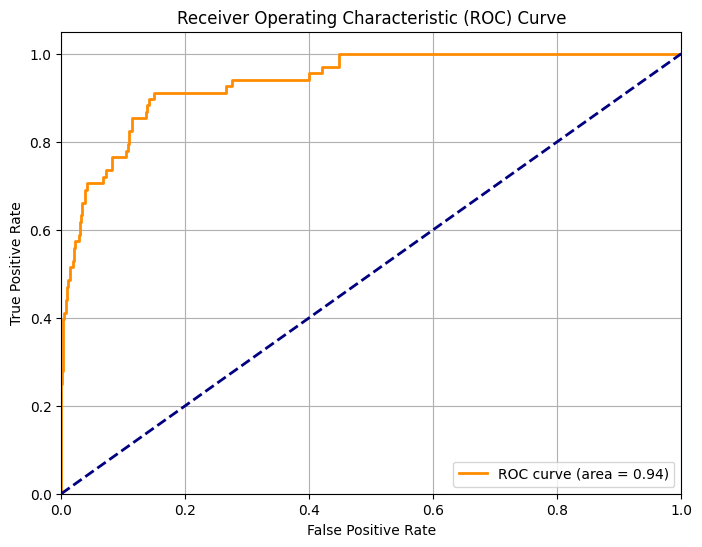

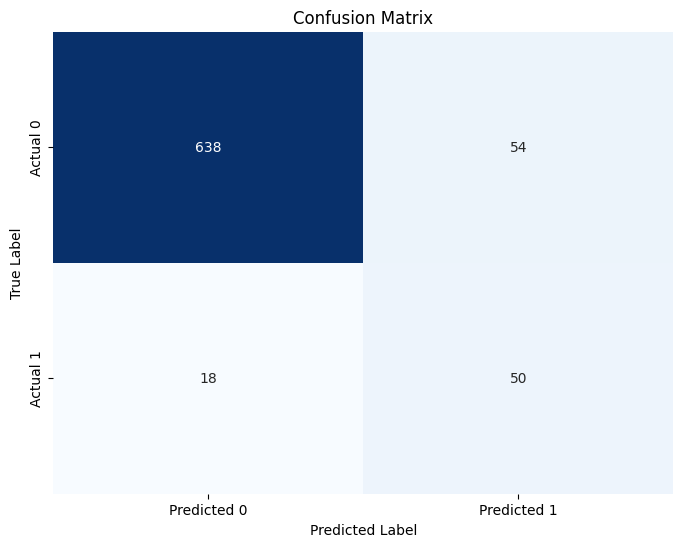

,Metric,Value
0,AUROC,0.937075
1,F1 (minority class),0.581395
2,Precision (minority),0.480769
3,Recall (minority),0.735294
4,Decision threshold used,0.210000


In [61]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, precision_score, recall_score
import seaborn as sns

# Load the final test data
with open('/content/drive/MyDrive/readmission-dl/data/X_final_test.pkl','rb') as f:
    X_final_test = pickle.load(f)
with open('/content/drive/MyDrive/readmission-dl/data/y_final_test.pkl','rb') as f:
    y_final_test = pickle.load(f)

# Load the paths to the best models from each fold
with open('/content/drive/MyDrive/readmission-dl/data/model_paths_for_ensemble.pkl', 'rb') as f:
    model_paths_for_ensemble = pickle.load(f)

# Convert X_final_test to tensor
X_final_test_tensor = torch.tensor(X_final_test, dtype=torch.float32)
y_final_test_tensor = torch.tensor(y_final_test, dtype=torch.float32).view(-1,1)

all_fold_predictions = []

# Load each model and get predictions for ensembling
for model_path in model_paths_for_ensemble:
    model = MLP(X_final_test_tensor.shape[1]) # Re-initialize the model structure
    model.load_state_dict(torch.load(model_path))
    model.eval() # Set model to evaluation mode

    with torch.no_grad():
        probs = torch.sigmoid(model(X_final_test_tensor)).numpy().flatten()
        all_fold_predictions.append(probs)

# Ensemble probabilities by averaging
ensembled_probs = np.mean(all_fold_predictions, axis=0)

# Load the calibrator and apply Platt Scaling
with open('/content/drive/MyDrive/readmission-dl/data/calibrator.pkl','rb') as f:
    calibrator = pickle.load(f)
calibrated_probs = calibrator.predict_proba(ensembled_probs.reshape(-1,1))[:,1]

# Load the best threshold
with open('/content/drive/MyDrive/readmission-dl/data/threshold.pkl','rb') as f:
    best_t = pickle.load(f)

# Convert true labels to numpy array for sklearn metrics
y_true = y_final_test_tensor.numpy().flatten()

# Predictions based on the best threshold
y_pred = (calibrated_probs > best_t).astype(int)

# 1. ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, calibrated_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# 3. Metrics in a table
metrics_data = {
    'Metric': [
        'AUROC',
        'F1 (minority class)',
        'Precision (minority)',
        'Recall (minority)',
        'Decision threshold used'
    ],
    'Value': [
        roc_auc,
        f1_score(y_true, y_pred, pos_label=1), # assuming 1 is minority class
        precision_score(y_true, y_pred, pos_label=1), # assuming 1 is minority class
        recall_score(y_true, y_pred, pos_label=1), # assuming 1 is minority class
        best_t
    ]
}

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df)


### 4.1 Precision-Recall Curve

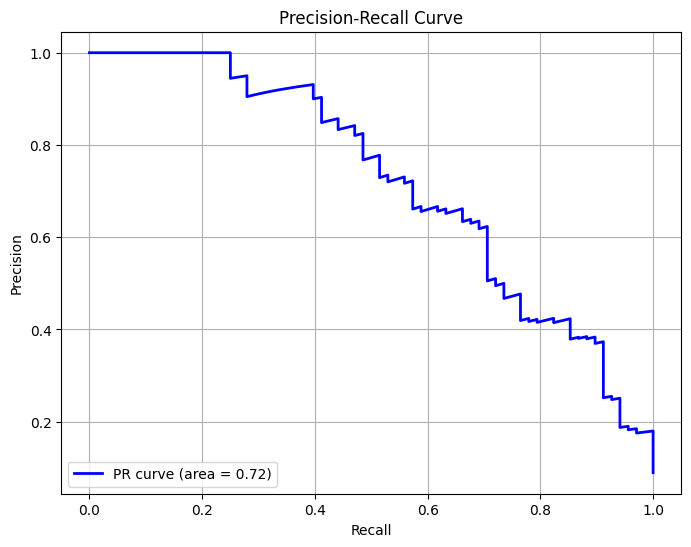

In [62]:
from sklearn.metrics import precision_recall_curve, auc

# Calculate Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_true, calibrated_probs)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

### 4.2 Class Probability Distributions

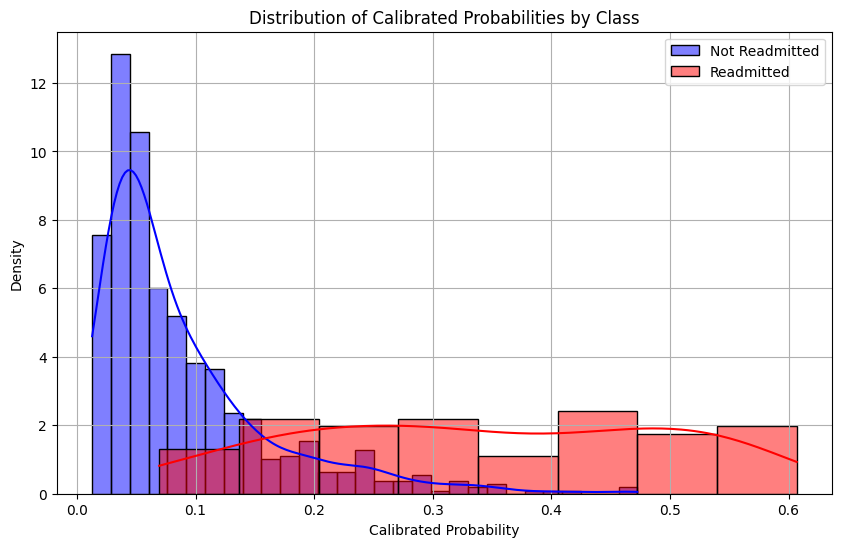

In [63]:
plt.figure(figsize=(10, 6))
sns.histplot(calibrated_probs[y_true == 0], color='blue', label='Not Readmitted', kde=True, stat='density', alpha=0.5)
sns.histplot(calibrated_probs[y_true == 1], color='red', label='Readmitted', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Calibrated Probabilities by Class')
plt.xlabel('Calibrated Probability')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

### 4.3 Feature Correlation Heatmap

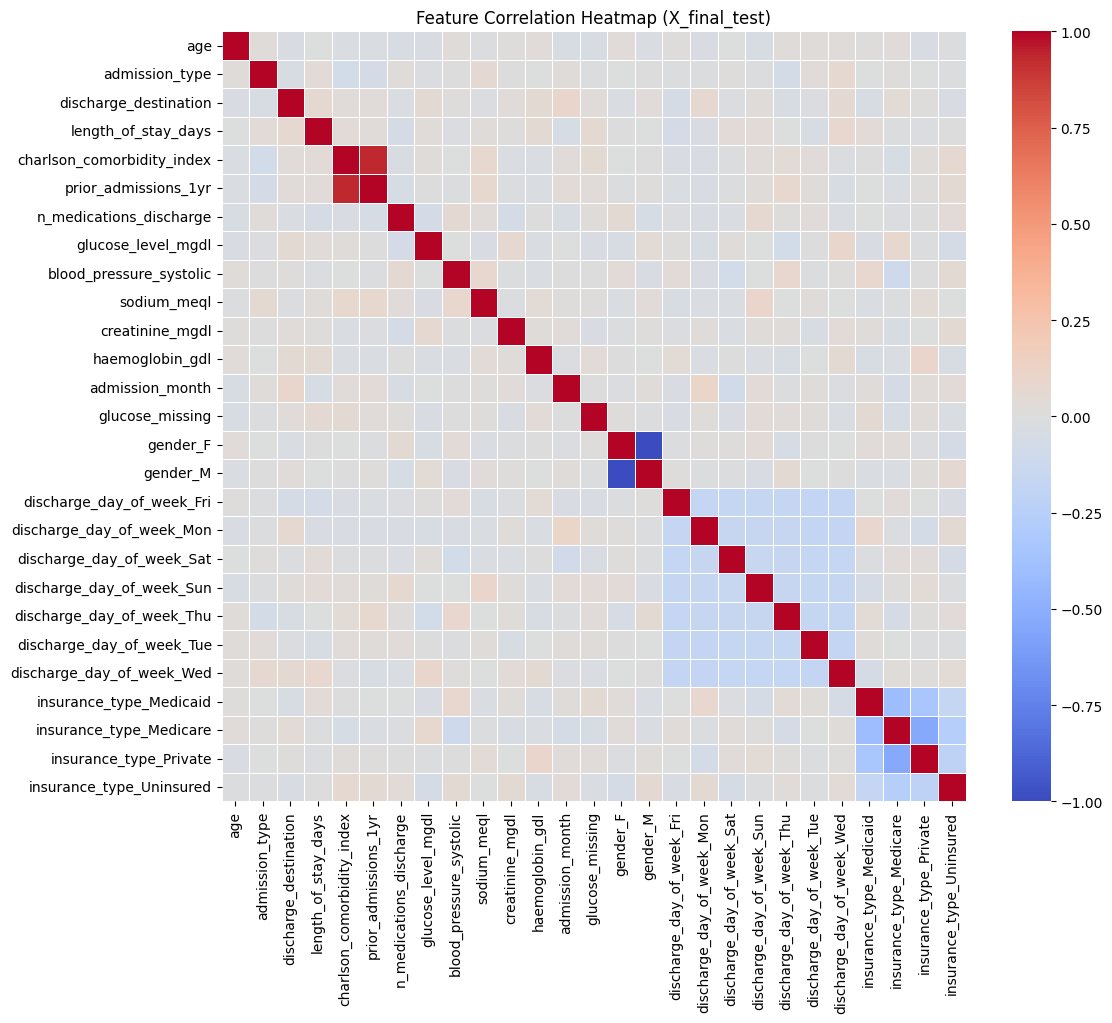

In [64]:
import pandas as pd

# Convert X_final_test back to a DataFrame for correlation calculation if possible
# For simplicity, we'll assume `columns` variable from preprocessing is available
# and represents the feature names after one-hot encoding and scaling.
# If `columns` is not available, this step would require re-running preprocessing up to get feature names.

# Let's assume `columns` variable was saved or is available from the training cell's scope.
# Since the training cells were executed, `columns` should be in the kernel state.

X_final_test_df = pd.DataFrame(X_final_test, columns=columns)

plt.figure(figsize=(12, 10))
sns.heatmap(X_final_test_df.corr(), cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Feature Correlation Heatmap (X_final_test)')
plt.show()

### 4.4 Loss Curve

In [65]:
from sklearn.linear_model import LogisticRegression
# Load the final test data
with open('/content/drive/MyDrive/readmission-dl/data/X_final_test.pkl','rb') as f:
    X_final_test = pickle.load(f)
with open('/content/drive/MyDrive/readmission-dl/data/y_final_test.pkl','rb') as f:
    y_final_test = pickle.load(f)

# Load the paths to the best models from each fold
with open('/content/drive/MyDrive/readmission-dl/data/model_paths_for_ensemble.pkl', 'rb') as f:
    model_paths_for_ensemble = pickle.load(f)

# Convert X_final_test to tensor
X_final_test_tensor = torch.tensor(X_final_test, dtype=torch.float32)
y_final_test_tensor = torch.tensor(y_final_test, dtype=torch.float32).view(-1,1)

all_fold_predictions = []

# Load each model and get predictions for ensembling
for model_path in model_paths_for_ensemble:
    model = MLP(X_final_test_tensor.shape[1]) # Re-initialize the model structure
    model.load_state_dict(torch.load(model_path))
    model.eval() # Set model to evaluation mode

    with torch.no_grad():
        probs = torch.sigmoid(model(X_final_test_tensor)).numpy().flatten()
        all_fold_predictions.append(probs)

# Ensemble probabilities by averaging
ensembled_probs = np.mean(all_fold_predictions, axis=0)

# Implement Platt Scaling
# Use 'lbfgs' solver for LogisticRegression when fitting probabilities
calibrator = LogisticRegression(solver='lbfgs', random_state=42)
calibrator.fit(ensembled_probs.reshape(-1,1), y_final_test)

calibrated_probs = calibrator.predict_proba(ensembled_probs.reshape(-1,1))[:,1]

best_f1 = 0
best_t = 0

for t in np.arange(0.1, 0.9, 0.01):
    preds = (calibrated_probs > t).astype(int)
    f1 = f1_score(y_final_test_tensor, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print('Best threshold for F1-score after ensembling and Platt scaling:', best_t)
print('F1-score at best threshold after ensembling and Platt scaling:', best_f1)

# Save the calibrator
artifact_path = '/content/drive/MyDrive/readmission-dl/data/'
with open(artifact_path + 'calibrator.pkl','wb') as f:
    pickle.dump(calibrator, f)
print(f"Calibrator model saved to: {artifact_path}calibrator.pkl")

Best threshold for F1-score after ensembling and Platt scaling: 0.20999999999999996
F1-score at best threshold after ensembling and Platt scaling: 0.6619718309859155
Calibrator model saved to: /content/drive/MyDrive/readmission-dl/data/calibrator.pkl


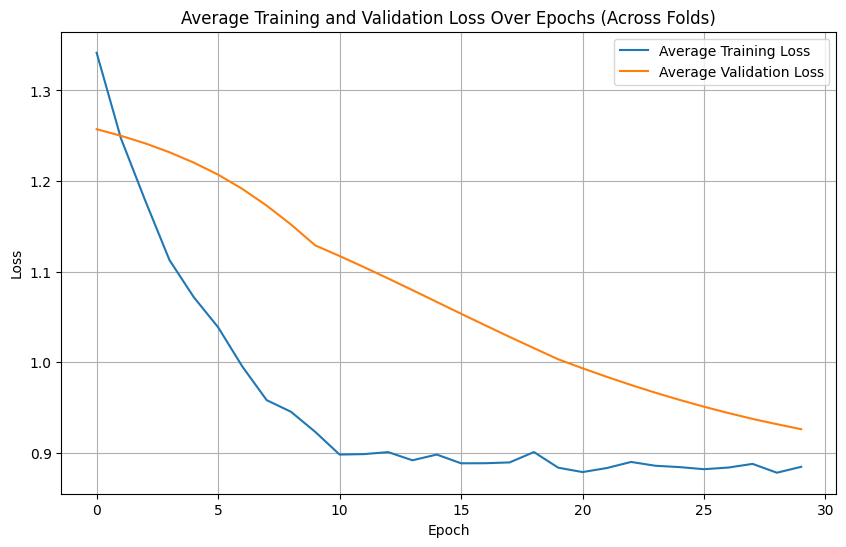

In [66]:
# Load the logged losses
with open('/content/drive/MyDrive/readmission-dl/data/train_losses_per_fold.pkl','rb') as f:
    all_train_losses_per_fold = pickle.load(f)
with open('/content/drive/MyDrive/readmission-dl/data/val_losses_per_fold.pkl','rb') as f:
    all_val_losses_per_fold = pickle.load(f)

# Convert to numpy arrays for easier averaging
train_losses_np = np.array(all_train_losses_per_fold)
val_losses_np = np.array(all_val_losses_per_fold)

# Calculate the average loss across folds for each epoch
avg_train_losses = np.mean(train_losses_np, axis=0)
avg_val_losses = np.mean(val_losses_np, axis=0)

# Plotting the average loss curves
plt.figure(figsize=(10, 6))
plt.plot(avg_train_losses, label='Average Training Loss')
plt.plot(avg_val_losses, label='Average Validation Loss')
plt.title('Average Training and Validation Loss Over Epochs (Across Folds)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [67]:
artifact_path = '/content/drive/MyDrive/readmission-dl/data/'

with open(artifact_path + 'scaler.pkl','wb') as f:
    pickle.dump(scaler,f)

with open(artifact_path + 'columns.pkl','wb') as f:
    pickle.dump(columns,f)

with open(artifact_path + 'glucose_median.pkl','wb') as f:
    pickle.dump(glucose_median,f)

with open(artifact_path + 'threshold.pkl','wb') as f:
    pickle.dump(best_t,f)

# Note: The calibrator.pkl is now saved directly in the threshold tuning cell.
print(f"Artifacts (scaler.pkl, columns.pkl, glucose_median.pkl, threshold.pkl, calibrator.pkl) saved to: {artifact_path}")

Artifacts (scaler.pkl, columns.pkl, glucose_median.pkl, threshold.pkl, calibrator.pkl) saved to: /content/drive/MyDrive/readmission-dl/data/
